# Analyse av COMPAS-data

Basert på fremgangsmåte gitt i oppgaveteksten

### Importering av biblioteker

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## a): Les inn og forstå dataene

### Innlesing av data

In [101]:
path = "../data/compas-scores-two-years.csv"
df = pd.read_csv(path, header=0)
print(len(df))
df.head()

7214


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


### Fjerner enkelte rader

Fjerner rader som bryter følgende krav i studien: 

"If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense"

In [102]:
df = df[df["days_b_screening_arrest"] <= 30]
df = df[df["days_b_screening_arrest"] >= -30]
print(len(df))

6172


Dette fjerner omtrent 1200 rader

### Forstå hva kolonnene betyr

Bruker kolonnene som ble brukt i ProPublicas analyse.

Forklaringsvariabler:
- "age_cat": Kategorisert alder på personen ved tidspunktet for COMPAS-vurderingen (typisk "Less than 25", "25 - 45", "Greater than 45"). Brukes i stedet for kontinuerlig alder.
- "race": Selvrapportert etnisitet/rasetilhørighet (f.eks. "African-American", "Caucasian"). Brukes for å undersøke forskjeller mellom grupper.
- "sex": Kjønn på personen (vanligvis "Male" eller "Female").
- "priors_count": Antall tidligere straffbare forhold før COMPAS-vurderingen. Brukes som mål på kriminell historikk.
- "c_charge_degree": Alvorlighetsgrad av den nåværende siktelsen. "F" betyr felony (alvorlig lovbrudd), "M" betyr misdemeanor (mindre alvorlig lovbrudd).
- "two_year_recid": Indikatorvariabel (0/1) for om personen begikk en ny straffbar handling innen to år etter COMPAS-vurderingen. Brukes som kontrollvariabel i analysen.

Target: 
- "score_text": COMPAS-algoritmens risikovurdering, kategorisert som "Low", "Medium" eller "High". I analysen slås ofte "Medium" og "High" sammen til én kategori for høy risiko.

### Fjerner kolonnene vi ikke trenger

In [103]:
df = df[["age_cat", "race", "sex", "priors_count", "c_charge_degree", "two_year_recid", "score_text"]].copy()

print(len(df))
df.head()

6172


,age_cat,race,sex,priors_count,c_charge_degree,two_year_recid,score_text
0,Greater than 45,Other,Male,0,F,0,Low
1,25 - 45,African-American,Male,0,F,1,Low
2,Less than 25,African-American,Male,4,F,1,Low
5,25 - 45,Other,Male,0,M,0,Low
6,25 - 45,Caucasian,Male,14,F,1,Medium


### Plots

1. Hvor ofte ulike grupperinger av mennesker (kvinner, menn, hvite og svarte) gjentar forbrytelser

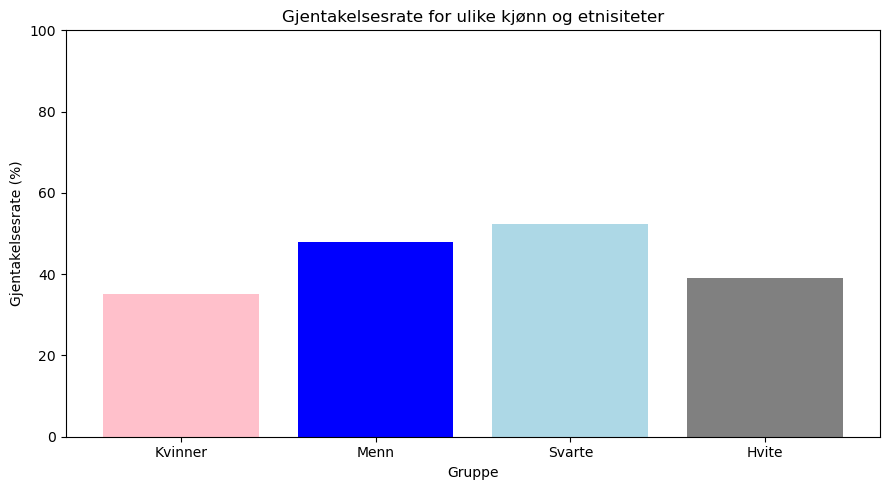

In [104]:
# Gjentakelsesrate per kjønn
gjenta_kjonn = df.groupby("sex")["two_year_recid"].mean() * 100
# Gjentakelsesrate per etnisitet
gjenta_etnisitet = df[df["race"].isin(["Caucasian", "African-American"])].groupby("race")["two_year_recid"].mean() * 100

# Slå sammen for samlet figur
labels = ["Kvinner", "Menn", "Svarte", "Hvite"]
values = list(gjenta_kjonn.values) + list(gjenta_etnisitet.values)
colors = ['pink', 'blue', 'lightblue', 'gray']

# Generer plot
plt.figure(figsize=(9, 5))
plt.bar(labels, values, color=colors)
plt.title("Gjentakelsesrate for ulike kjønn og etnisiteter")
plt.ylabel("Gjentakelsesrate (%)")
plt.xlabel("Gruppe")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("../figurer/gjentakelsesrate_kjonn_etnisitet.pdf", format="pdf")
plt.show()

2. Hvor ofte ulike grupperinger av mennesker (kviner, menn, hvite og svarte) blir predikert av algoritmen til å begå straffbare handlinger i fremtiden

Altså: Hvor ofte får ulike grupper score medium eller high 

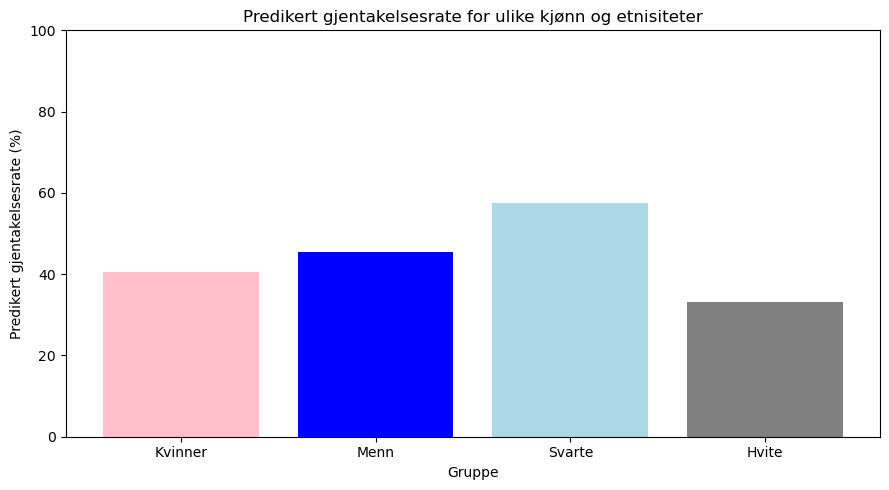

In [105]:
# Lager kolonne for predikert gjentakelse
df["high_risk"] = df["score_text"] != "Low"

# Prediksjonsrate kjønn
pred_kjonn = df.groupby("sex")["high_risk"].mean() * 100
# Prediksjonsrate etnisitet
pred_etnisitet = df[df["race"].isin(["Caucasian", "African-American"])].groupby("race")["high_risk"].mean() * 100

# Slå sammen for samlet figur
labels = ["Kvinner", "Menn", "Svarte", "Hvite"]
values = list(pred_kjonn.values) + list(pred_etnisitet.values)
colors = ['pink', 'blue', 'lightblue', 'gray']

# Generer figur
plt.figure(figsize=(9, 5))
plt.bar(labels, values, color=colors)
plt.title("Predikert gjentakelsesrate for ulike kjønn og etnisiteter")
plt.ylabel("Predikert gjentakelsesrate (%)")
plt.xlabel("Gruppe")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("../figurer/predikert_gjentakelsesrate_kjonn_etnisitet.pdf", format="pdf")
plt.show()

3. Hvor ofte ulike grupper fikk ulike risikoskårer

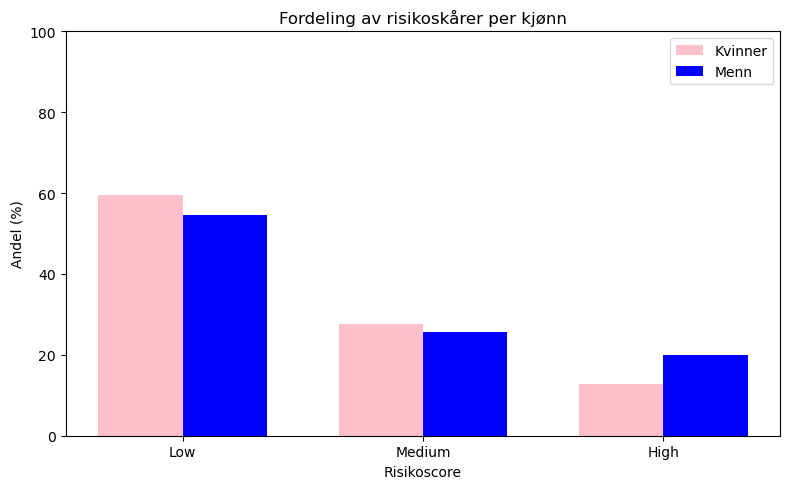

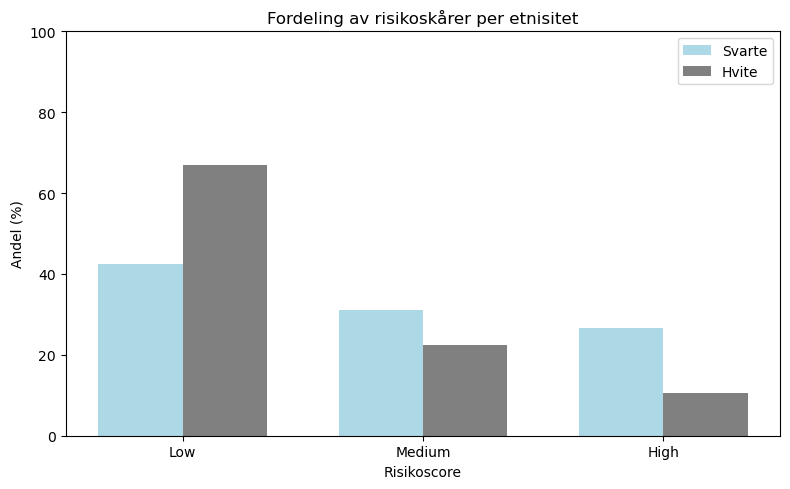

In [106]:
# Fordeling av score_text per kjønn
score_by_sex = pd.crosstab(df['sex'], df['score_text'], normalize='index') * 100
score_by_sex = score_by_sex[['Low', 'Medium', 'High']]  # Sorter kolonner

# Fordeling av score_text per etnisitet
race_df = df[df["race"].isin(["Caucasian", "African-American"])]
score_by_race = pd.crosstab(race_df["race"], race_df["score_text"], normalize="index") * 100

score_by_race = score_by_race[['Low', 'Medium', 'High']]  # Sorter kolonner

# Plot for kjønn
fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35  # Bredde på hver undersøyle
x = np.arange(len(score_by_sex.columns))  # Posisjoner for Low, Medium, High

ax.bar(x - width/2, score_by_sex.loc['Female'], width, label='Kvinner', color='pink')
ax.bar(x + width/2, score_by_sex.loc['Male'], width, label='Menn', color='blue')

ax.set_xlabel('Risikoscore')
ax.set_ylabel('Andel (%)')
ax.set_title('Fordeling av risikoskårer per kjønn')
ax.set_xticks(x)
ax.set_xticklabels(score_by_sex.columns)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("../figurer/score_fordeling_kjonn_grouped.pdf", format="pdf")
plt.show()

# Plot for etnisitet
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(score_by_race.columns))  # Posisjoner for Low, Medium, High

ax.bar(x - width/2, score_by_race.loc['African-American'], width, label='Svarte', color='lightblue')
ax.bar(x + width/2, score_by_race.loc['Caucasian'], width, label='Hvite', color='gray')

ax.set_xlabel('Risikoscore')
ax.set_ylabel('Andel (%)')
ax.set_title('Fordeling av risikoskårer per etnisitet')
ax.set_xticks(x)
ax.set_xticklabels(score_by_race.columns)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("../figurer/score_fordeling_etnisitet_grouped.pdf", format="pdf")
plt.show()

4. Hvor ofte de som begikk straffbare handlinger (og de som ikke gjorde det) fikk ulike risikoskårer, og hvordan dette ser ut hvis du kun ser på hvite eller svarte

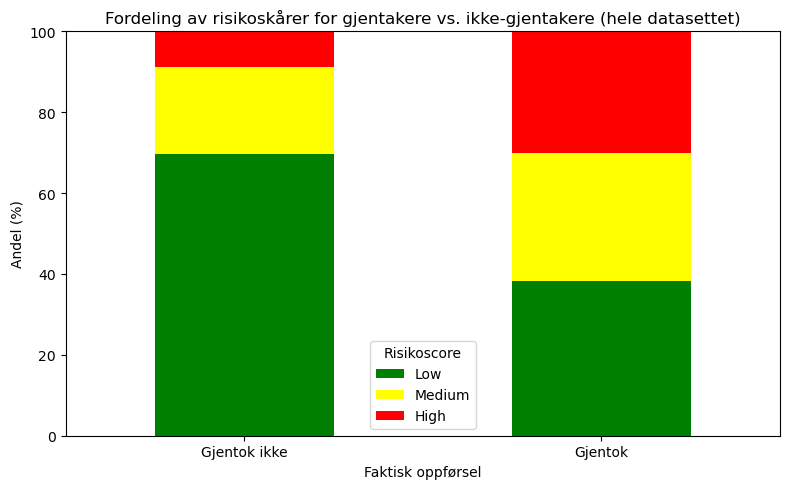

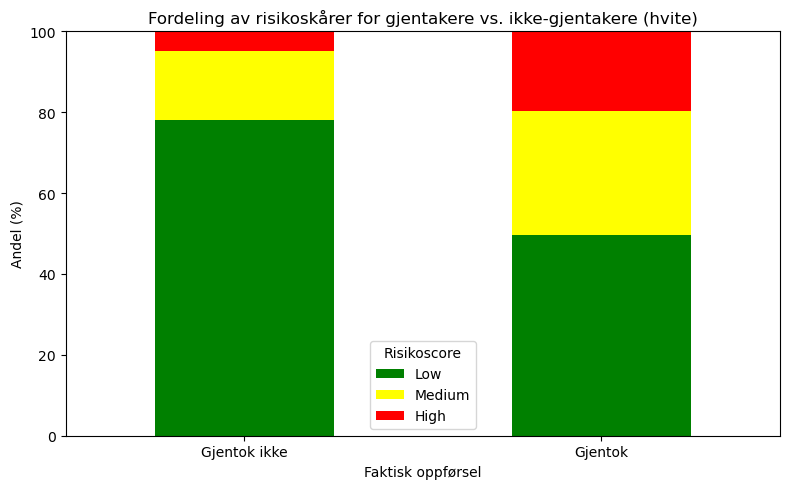

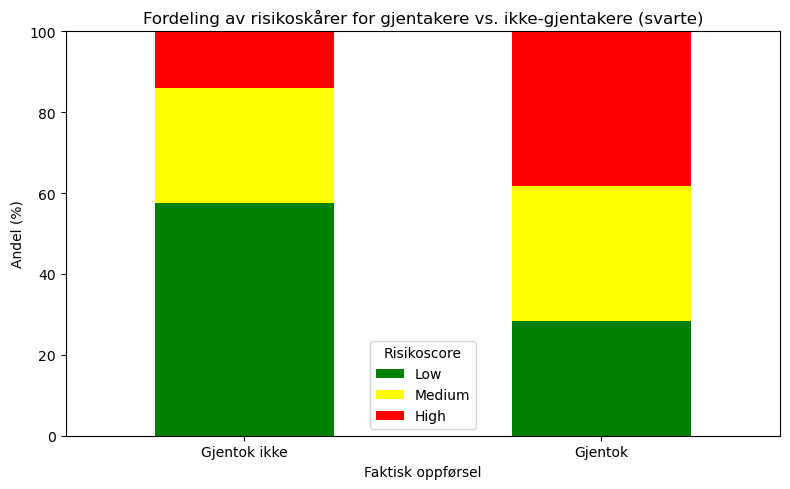

In [107]:
# Overall fordeling av score_text per recidivism
overall = pd.crosstab(df['two_year_recid'], df['score_text'], normalize='index') * 100
overall = overall[['Low', 'Medium', 'High']]  
overall.index = ['Gjentok ikke', 'Gjentok']  

# Plot overall
overall.plot(kind='bar', stacked=True, figsize=(8, 5), color=['green', 'yellow', 'red'])
plt.title("Fordeling av risikoskårer for gjentakere vs. ikke-gjentakere (hele datasettet)")
plt.ylabel("Andel (%)")
plt.xlabel("Faktisk oppførsel")
plt.xticks(rotation=0)  
plt.legend(title="Risikoscore")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("../figurer/score_fordeling_gjentakels_alle.pdf", format="pdf")
plt.show()

# For hvite (Caucasian)
white_df = df[df['race'] == 'Caucasian']
white = pd.crosstab(white_df['two_year_recid'], white_df['score_text'], normalize='index') * 100
white = white[['Low', 'Medium', 'High']]
white.index = ['Gjentok ikke', 'Gjentok']

white.plot(kind='bar', stacked=True, figsize=(8, 5), color=['green', 'yellow', 'red'])
plt.title("Fordeling av risikoskårer for gjentakere vs. ikke-gjentakere (hvite)")
plt.ylabel("Andel (%)")
plt.xlabel("Faktisk oppførsel")
plt.xticks(rotation=0)
plt.legend(title="Risikoscore")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("../figurer/score_fordeling_gjentakelse_hvite.pdf", format="pdf")
plt.show()

# For svarte (African-American)
black_df = df[df['race'] == 'African-American']
black = pd.crosstab(black_df['two_year_recid'], black_df['score_text'], normalize='index') * 100
black = black[['Low', 'Medium', 'High']]
black.index = ['Gjentok ikke', 'Gjentok']

black.plot(kind='bar', stacked=True, figsize=(8, 5), color=['green', 'yellow', 'red'])
plt.title("Fordeling av risikoskårer for gjentakere vs. ikke-gjentakere (svarte)")
plt.ylabel("Andel (%)")
plt.xlabel("Faktisk oppførsel")
plt.xticks(rotation=0)
plt.legend(title="Risikoscore")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("../figurer/score_fordeling_gjentakelse_svarte.pdf", format="pdf")
plt.show()

## b) Rater

Falske positive, falske negative, sanne positive, sanne negative, positiv prediktiv verdi for:
- Hele befolkningen
- Kvinner
- Menn
- Hvite
- Svarte

Har definerert high_risk kolonne som personer som fikk predikert "High" eller "Medium" 

Sanne positive defineres som de som ble predikert som high_risk og utførte forbrytelse innen to år.

In [108]:
df["high_risk"] = (df["high_risk"]).astype(int)
df.head()

,age_cat,race,sex,priors_count,c_charge_degree,two_year_recid,score_text,high_risk
0,Greater than 45,Other,Male,0,F,0,Low,0
1,25 - 45,African-American,Male,0,F,1,Low,0
2,Less than 25,African-American,Male,4,F,1,Low,0
5,25 - 45,Other,Male,0,M,0,Low,0
6,25 - 45,Caucasian,Male,14,F,1,Medium,1


Funksjon som beregner:
- TP: Sanne positive
- TN: Sanne negative
- FP: Falske positive
- FN: Falske negative
- PPV: Positiv prediktiv verdi


Ratene beregnes ikke av totalt antall observasjoner. Eksempel: FP(rate) = FP / FP + TN
"Av alle faktiske negative, ble så mange feilaktig klassifisert som positive"

In [109]:
def confusion_stats(df):
    TP_tot = int(((df["high_risk"] == 1) & (df["two_year_recid"] == 1)).sum())
    FP_tot = int(((df["high_risk"] == 1) & (df["two_year_recid"] == 0)).sum())
    TN_tot = int(((df["high_risk"] == 0) & (df["two_year_recid"] == 0)).sum())
    FN_tot = int(((df["high_risk"] == 0) & (df["two_year_recid"] == 1)).sum())
    
    TPR = TP_tot / (TP_tot + FN_tot)
    FPR = FP_tot / (FP_tot + TN_tot)
    TNR = TN_tot / (TN_tot + FP_tot)
    FNR = FN_tot / (FN_tot + TP_tot)
    PPV = TP_tot / (TP_tot + FP_tot)
    
    return {
        "TPR": TPR, 
        "FPR": FPR, 
        "TNR": TNR, 
        "FNR": FNR, 
        "PPV": PPV}

Lager dictionary med gruppene som skal itereres over:

In [110]:
groups = {
    "Hele": df,
    "Kvinner": df[df["sex"] == "Female"],
    "Menn": df[df["sex"] == "Male"],
    "Hvite": df[df["race"] == "Caucasian"],
    "Svarte": df[df["race"] == "African-American"],
}

Iterer gjennom groups:

In [111]:
rows = []
for name, data_frame in groups.items():
    stats = confusion_stats(data_frame)
    stats["Group"] = name
    rows.append(stats)

result = pd.DataFrame(rows).set_index("Group")
result

,TPR,FPR,TNR,FNR,PPV
Group,,,,,
Hele,0.616946,0.302706,0.697294,0.383054,0.629953
Kvinner,0.595642,0.301837,0.698163,0.404358,0.516807
Menn,0.620618,0.302960,0.697040,0.379382,0.653626
Hvite,0.503650,0.220141,0.779859,0.496350,0.594828
Svarte,0.715232,0.423382,0.576618,0.284768,0.649535


## c) Sammenheng med Bayes' setning


Bayes' setning forklarer hvorfor det er en sammenheng mellom presisjon og forskjeller mellom grupper. Hvis vi lar $A$ bety at en person faktisk gjentar kriminalitet innen to år, og $B$ bety at COMPAS gir personen høy risiko, får vi:

$$
P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}
$$

Her er $P(A \mid B)$ den **positive prediktive verdien** (PPV): sannsynligheten for at en person faktisk gjentar kriminalitet gitt at modellen har klassifisert personen som høy risiko.

- $P(B \mid A)$ tilsvarer i praksis **TPR**: andelen av de som faktisk gjentar kriminalitet som COMPAS fanger opp som høy risiko.
- $P(A)$ er **base rate**: hvor vanlig tilbakefall faktisk er i gruppen.
- $P(B)$ er hvor stor andel av gruppen som får prediksjonen høy risiko.

Dette betyr at PPV ikke bare avhenger av hvor god modellen er, men også av hvor høy den faktiske tilbakefallsraten er i gruppen. Hvis to grupper har ulik base rate $P(A)$, vil de derfor kunne få ulik PPV selv om modellen har samme TPR og FPR i begge gruppene.

Det er dette som skaper spenningen mellom ulike rettferdighetsmål. Når grupper har forskjellig tilbakefallsrate i utgangspunktet, er det vanskelig å samtidig ha like feilrater og lik presisjon. Hvis man justerer modellen slik at PPV blir likere mellom gruppene, vil ofte FPR eller FNR bli mer forskjellige. Hvis man i stedet prøver å gjøre feilratene like, vil PPV ofte bli ulik.

I våre resultater ser vi nettopp en slik sammenheng: svarte har høyere TPR, men også høyere FPR, og de har samtidig noe høyere PPV enn hvite. Bayes' setning viser at dette ikke er tilfeldig, men henger sammen med at både base rate og andelen som får høy risiko varierer mellom gruppene. Derfor kan man ikke uten videre kreve at alle disse målene skal være like samtidig.
